In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results" / "labels"
FIG_DIR = PROJECT_ROOT / "figures" / "labels"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

parquet_path = DATA_DIR / "supermarket_prices_tidy.parquet"

df = pd.read_parquet(parquet_path)

df.shape

(9497591, 13)

In [2]:
label_df = df[[
    "product_id",
    "retailer",
    "category",
    "date",
    "price",
    "capture_gap_before_row",
    "days_since_previous_capture",
    "own_brand_flag"
]].copy()

label_df = label_df[
    label_df["price"].notna() &
    (label_df["price"] > 0)
].copy()

label_df = label_df.sort_values(
    ["retailer", "product_id", "date"]
).reset_index(drop=True)

label_df.shape

(9497581, 8)

In [3]:
group_cols = ["retailer", "product_id"]

label_df["future_price_h1"] = (
    label_df
    .groupby(group_cols, observed=True)["price"]
    .shift(-1)
)

label_df["future_date_h1"] = (
    label_df
    .groupby(group_cols, observed=True)["date"]
    .shift(-1)
)

label_df["future_capture_gap_h1"] = (
    label_df
    .groupby(group_cols, observed=True)["capture_gap_before_row"]
    .shift(-1)
)

label_df[[
    "retailer",
    "product_id",
    "date",
    "price",
    "future_date_h1",
    "future_price_h1",
    "future_capture_gap_h1"
]].head(20)

,retailer,product_id,date,price,future_date_h1,future_price_h1,future_capture_gap_h1
0,ASDA,asda_000001,2024-01-09,15.0,2024-01-10,15.0,False
1,ASDA,asda_000001,2024-01-10,15.0,2024-01-11,15.0,False
2,ASDA,asda_000001,2024-01-11,15.0,2024-01-12,15.0,False
3,ASDA,asda_000001,2024-01-12,15.0,2024-01-13,15.0,False
4,ASDA,asda_000001,2024-01-13,15.0,2024-01-14,15.0,False
5,ASDA,asda_000001,2024-01-14,15.0,2024-01-15,15.0,False
6,ASDA,asda_000001,2024-01-15,15.0,2024-01-16,15.0,False
7,ASDA,asda_000001,2024-01-16,15.0,2024-01-18,15.0,True
8,ASDA,asda_000001,2024-01-18,15.0,2024-01-19,15.0,False
9,ASDA,asda_000001,2024-01-19,15.0,2024-01-20,15.0,False


In [4]:
label_df["valid_label_h1"] = (
    label_df["future_price_h1"].notna() &
    (~label_df["future_capture_gap_h1"].fillna(False))
)

label_df["valid_label_h1"].value_counts(dropna=False)

valid_label_h1
True     8711346
False     786235
Name: count, dtype: Int64

In [5]:
label_df["forward_pct_change_h1"] = np.where(
    label_df["valid_label_h1"] &
    (label_df["price"] > 0),
    ((label_df["future_price_h1"] - label_df["price"]) / label_df["price"]) * 100,
    np.nan
)

label_df[[
    "retailer",
    "product_id",
    "date",
    "price",
    "future_price_h1",
    "forward_pct_change_h1",
    "valid_label_h1"
]].head(20)

,retailer,product_id,date,price,future_price_h1,forward_pct_change_h1,valid_label_h1
0,ASDA,asda_000001,2024-01-09,15.0,15.0,0.0,True
1,ASDA,asda_000001,2024-01-10,15.0,15.0,0.0,True
2,ASDA,asda_000001,2024-01-11,15.0,15.0,0.0,True
3,ASDA,asda_000001,2024-01-12,15.0,15.0,0.0,True
4,ASDA,asda_000001,2024-01-13,15.0,15.0,0.0,True
5,ASDA,asda_000001,2024-01-14,15.0,15.0,0.0,True
6,ASDA,asda_000001,2024-01-15,15.0,15.0,0.0,True
7,ASDA,asda_000001,2024-01-16,15.0,15.0,NaN,False
8,ASDA,asda_000001,2024-01-18,15.0,15.0,0.0,True
9,ASDA,asda_000001,2024-01-19,15.0,15.0,0.0,True


In [6]:
PRIMARY_TOLERANCE = 0.5

label_df["target_direction_h1_t05"] = np.select(
    [
        label_df["valid_label_h1"] & (label_df["forward_pct_change_h1"] > PRIMARY_TOLERANCE),
        label_df["valid_label_h1"] & (label_df["forward_pct_change_h1"] < -PRIMARY_TOLERANCE),
        label_df["valid_label_h1"] & (label_df["forward_pct_change_h1"].between(-PRIMARY_TOLERANCE, PRIMARY_TOLERANCE)),
    ],
    [
        "Up",
        "Down",
        "Stable",
    ],
    default=np.nan
)

label_df[[
    "retailer",
    "product_id",
    "date",
    "price",
    "future_price_h1",
    "forward_pct_change_h1",
    "valid_label_h1",
    "target_direction_h1_t05"
]].head(30)

TypeError: Choicelist and default value do not have a common dtype: The DType <class 'numpy.dtypes._PyFloatDType'> could not be promoted by <class 'numpy.dtypes.StrDType'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes._PyFloatDType'>)

In [7]:
"Up", "Down", "Stable"

('Up', 'Down', 'Stable')

In [8]:
np.nan

nan

In [9]:
PRIMARY_TOLERANCE = 0.5

label_df["target_direction_h1_t05"] = np.select(
    [
        label_df["valid_label_h1"] & (label_df["forward_pct_change_h1"] > PRIMARY_TOLERANCE),
        label_df["valid_label_h1"] & (label_df["forward_pct_change_h1"] < -PRIMARY_TOLERANCE),
        label_df["valid_label_h1"] & (label_df["forward_pct_change_h1"].between(-PRIMARY_TOLERANCE, PRIMARY_TOLERANCE)),
    ],
    [
        "Up",
        "Down",
        "Stable",
    ],
    default=None
)

label_df["target_direction_h1_t05"] = pd.Categorical(
    label_df["target_direction_h1_t05"],
    categories=["Down", "Stable", "Up"],
    ordered=True
)

label_df[[
    "retailer",
    "product_id",
    "date",
    "price",
    "future_price_h1",
    "forward_pct_change_h1",
    "valid_label_h1",
    "target_direction_h1_t05"
]].head(30)

,retailer,product_id,date,price,future_price_h1,forward_pct_change_h1,valid_label_h1,target_direction_h1_t05
0,ASDA,asda_000001,2024-01-09,15.0,15.0,0.0,True,Stable
1,ASDA,asda_000001,2024-01-10,15.0,15.0,0.0,True,Stable
2,ASDA,asda_000001,2024-01-11,15.0,15.0,0.0,True,Stable
3,ASDA,asda_000001,2024-01-12,15.0,15.0,0.0,True,Stable
4,ASDA,asda_000001,2024-01-13,15.0,15.0,0.0,True,Stable
5,ASDA,asda_000001,2024-01-14,15.0,15.0,0.0,True,Stable
6,ASDA,asda_000001,2024-01-15,15.0,15.0,0.0,True,Stable
7,ASDA,asda_000001,2024-01-16,15.0,15.0,NaN,False,NaN
8,ASDA,asda_000001,2024-01-18,15.0,15.0,0.0,True,Stable
9,ASDA,asda_000001,2024-01-19,15.0,15.0,0.0,True,Stable


In [10]:
valid_class_counts_h1_t05 = (
    label_df
    .loc[label_df["valid_label_h1"], "target_direction_h1_t05"]
    .value_counts()
    .rename_axis("target_direction")
    .reset_index(name="count")
)

valid_class_counts_h1_t05["share"] = (
    valid_class_counts_h1_t05["count"] / valid_class_counts_h1_t05["count"].sum()
)

valid_class_counts_h1_t05

,target_direction,count,share
0,Stable,8575935,0.984456
1,Up,68005,0.007806
2,Down,67406,0.007738


In [13]:
valid_class_counts_h1_t05.to_csv(
    RESULTS_DIR / "class_split_h1_tolerance_0_5.csv",
    index=False
)

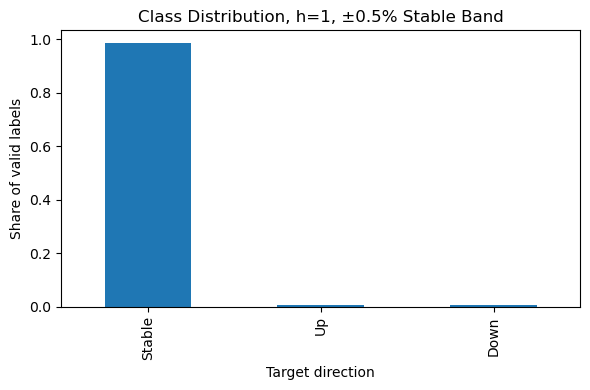

In [12]:
plt.figure(figsize=(6, 4))
valid_class_counts_h1_t05.set_index("target_direction")["share"].plot(kind="bar")
plt.xlabel("Target direction")
plt.ylabel("Share of valid labels")
plt.title("Class Distribution, h=1, ±0.5% Stable Band")
plt.tight_layout()
plt.savefig(FIG_DIR / "class_distribution_h1_tolerance_0_5.png", dpi=300)
plt.show()

In [14]:
valid_class_counts_h1_t05.to_csv(
    RESULTS_DIR / "class_split_h1_tolerance_0_5.csv",
    index=False
)

In [15]:
label_output_cols = [
    "product_id",
    "retailer",
    "category",
    "date",
    "price",
    "own_brand_flag",
    "capture_gap_before_row",
    "days_since_previous_capture",
    "future_date_h1",
    "future_price_h1",
    "valid_label_h1",
    "forward_pct_change_h1",
    "target_direction_h1_t05",
]

labelled_h1_t05 = label_df[label_output_cols].copy()

labelled_h1_t05.to_parquet(
    DATA_DIR / "supermarket_prices_labelled_h1_tolerance_0_5.parquet",
    index=False
)

labelled_h1_t05.shape

(9497581, 13)

In [17]:
def create_forward_label_summary(base_df, horizon, tolerance):
    temp = base_df.copy()

    group_cols = ["retailer", "product_id"]

    future_price_col = f"future_price_h{horizon}"
    future_date_col = f"future_date_h{horizon}"
    forward_change_col = f"forward_pct_change_h{horizon}"
    valid_label_col = f"valid_label_h{horizon}"
    target_col = f"target_direction_h{horizon}_t{str(tolerance).replace('.', '')}"

    temp[future_price_col] = (
        temp.groupby(group_cols, observed=True)["price"].shift(-horizon)
    )

    temp[future_date_col] = (
        temp.groupby(group_cols, observed=True)["date"].shift(-horizon)
    )

    # Valid only if future row exists
    temp[valid_label_col] = temp[future_price_col].notna()

    # Also require no capture gap in any future step from t+1 to t+h
    for step in range(1, horizon + 1):
        future_gap_step = (
            temp.groupby(group_cols, observed=True)["capture_gap_before_row"].shift(-step)
        )
        temp[valid_label_col] = (
            temp[valid_label_col] &
            (~future_gap_step.fillna(False))
        )

    temp[forward_change_col] = np.where(
        temp[valid_label_col] & (temp["price"] > 0),
        ((temp[future_price_col] - temp["price"]) / temp["price"]) * 100,
        np.nan
    )

    temp[target_col] = np.select(
        [
            temp[valid_label_col] & (temp[forward_change_col] > tolerance),
            temp[valid_label_col] & (temp[forward_change_col] < -tolerance),
            temp[valid_label_col] & (temp[forward_change_col].between(-tolerance, tolerance)),
        ],
        ["Up", "Down", "Stable"],
        default=None
    )

    counts = (
        temp.loc[temp[valid_label_col], target_col]
        .value_counts()
        .rename_axis("target_direction")
        .reset_index(name="count")
    )

    counts["share"] = counts["count"] / counts["count"].sum()
    counts["horizon"] = horizon
    counts["tolerance_percent"] = tolerance
    counts["valid_labels"] = counts["count"].sum()

    return counts

In [18]:
horizons = [1, 2, 3]
tolerances = [0.25, 0.5, 1.0]

sensitivity_results = []

for h in horizons:
    for tol in tolerances:
        print(f"Processing horizon={h}, tolerance={tol}")
        summary = create_forward_label_summary(label_df, horizon=h, tolerance=tol)
        sensitivity_results.append(summary)

sensitivity_summary = pd.concat(sensitivity_results, ignore_index=True)

sensitivity_summary

Processing horizon=1, tolerance=0.25
Processing horizon=1, tolerance=0.5
Processing horizon=1, tolerance=1.0
Processing horizon=2, tolerance=0.25
Processing horizon=2, tolerance=0.5
Processing horizon=2, tolerance=1.0
Processing horizon=3, tolerance=0.25
Processing horizon=3, tolerance=0.5
Processing horizon=3, tolerance=1.0


,target_direction,count,share,horizon,tolerance_percent,valid_labels
0,Stable,8575828,0.984444,1,0.25,8711346
1,Up,68059,0.007813,1,0.25,8711346
2,Down,67459,0.007744,1,0.25,8711346
3,Stable,8575935,0.984456,1,0.50,8711346
4,Up,68005,0.007806,1,0.50,8711346
5,Down,67406,0.007738,1,0.50,8711346
6,Stable,8576087,0.984473,1,1.00,8711346
7,Up,67924,0.007797,1,1.00,8711346
8,Down,67335,0.007730,1,1.00,8711346
9,Stable,7744886,0.971324,2,0.25,7973538


In [19]:
sensitivity_summary.to_csv(
    RESULTS_DIR / "label_sensitivity_horizons_tolerances.csv",
    index=False
)

In [20]:
sensitivity_summary.to_csv(
    RESULTS_DIR / "label_sensitivity_horizons_tolerances.csv",
    index=False
)

In [21]:
sensitivity_pivot = (
    sensitivity_summary
    .pivot_table(
        index=["horizon", "tolerance_percent"],
        columns="target_direction",
        values="share",
        aggfunc="first"
    )
    .reset_index()
)

sensitivity_pivot

target_direction,horizon,tolerance_percent,Down,Stable,Up
0,1,0.25,0.007744,0.984444,0.007813
1,1,0.50,0.007738,0.984456,0.007806
2,1,1.00,0.007730,0.984473,0.007797
3,2,0.25,0.014285,0.971324,0.014392
4,2,0.50,0.014275,0.971345,0.014380
5,2,1.00,0.014261,0.971374,0.014365
6,3,0.25,0.020294,0.959229,0.020477
7,3,0.50,0.020280,0.959261,0.020458
8,3,1.00,0.020261,0.959302,0.020437


In [22]:
sensitivity_pivot.to_csv(
    RESULTS_DIR / "label_sensitivity_pivot.csv",
    index=False
)